# 2.2. Transformations

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Hàm dùng để hiển thị ảnh

In [7]:
def show_plt(tittle, img):
    plt.title(tittle)
    plt.axis("off")

    if img.ndim == 2:
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)

## Load image

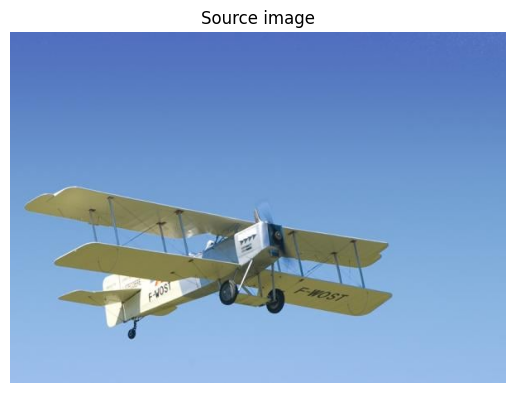

In [8]:
img_path = "../Images/source3.jpg"
img = cv2.imread(img_path, cv2.IMREAD_COLOR)

show_plt("Source image", img)

In [46]:
h, w = img.shape[:2]

## Translation

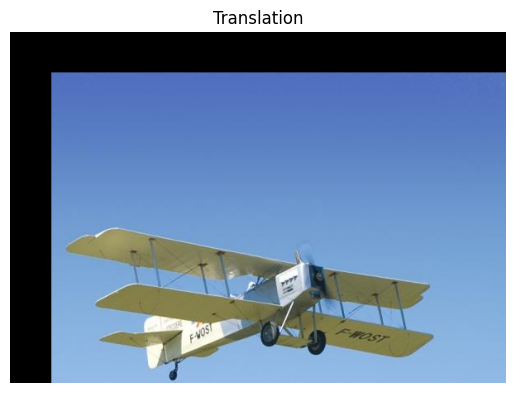

In [ ]:
tx, ty = 50, 50

translation_matrix = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

translated_img = cv2.warpAffine(img, translation_matrix, (w, h))

show_plt("Translation", translated_img)

## Rotation

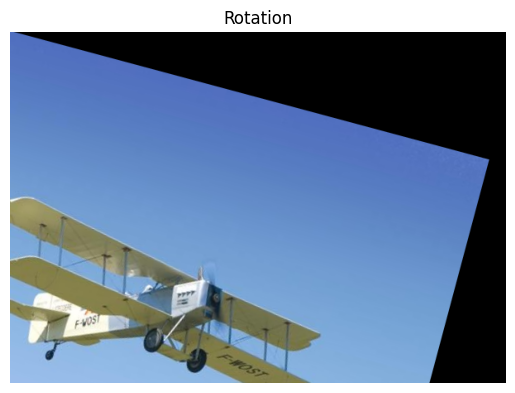

In [49]:
angle = np.deg2rad(15)

rotation_matrix = np.float32([
    [np.cos(angle), -np.sin(angle), 0],
    [np.sin(angle), np.cos(angle), 0]
])

rotated_image = cv2.warpAffine(img, rotation_matrix, (w,h))

show_plt("Rotation", rotated_image)

## Scaling

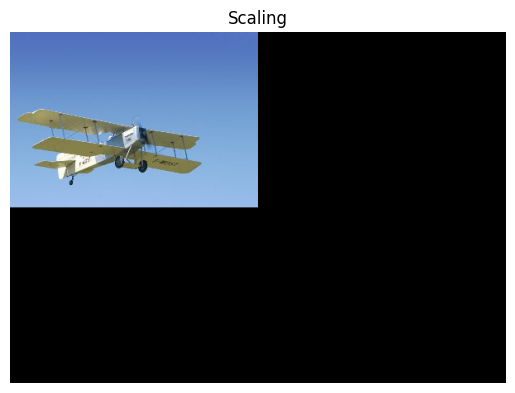

In [ ]:
sx = 0.5
sy = 0.5

scaled_matrix = np.float32([
    [sx, 0, 0],
    [0, sy, 0]
])

scaled_img = cv2.warpAffine(img, scaled_matrix, (w, h))

show_plt("Scaling", scaled_img)

## Shearing

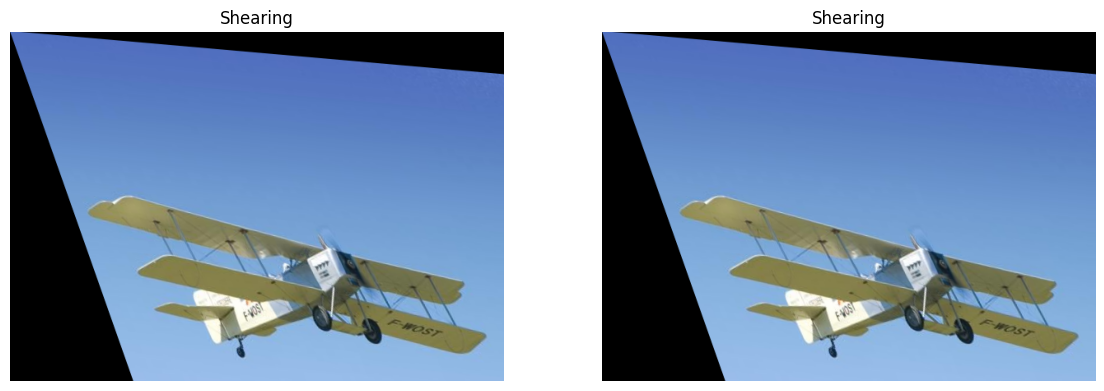

In [ ]:
theta_x = np.deg2rad(70)
theta_y = np.deg2rad(85)

sheared_matrix = np.float32([
    [1, 1/np.tan(theta_x), 0],
    [1/np.tan(theta_y), 1 + 1/(np.tan(theta_x)*np.tan(theta_y)), 0]
])

sheared_matrix2 = np.float32([
    [1, 0.36397, 0],
    [0.0875, 1 + 0.0872*0.36397, 0]
])

sheared_img = cv2.warpAffine(img, sheared_matrix, (w, h))
sheared_img2 = cv2.warpAffine(img, sheared_matrix2, (w, h))

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
show_plt("Shearing", sheared_img)
plt.subplot(1,2,2)
show_plt("Shearing", sheared_img2)

## Affine Transformation

### Rotation + Translation

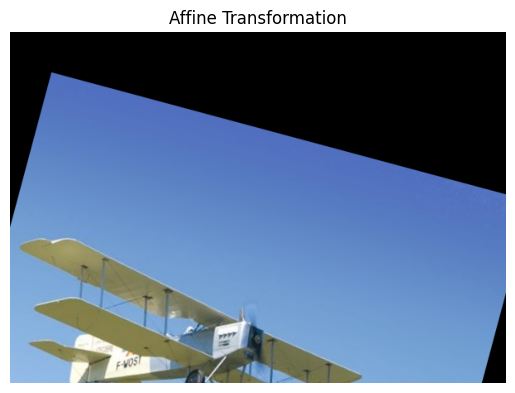

In [50]:
theta = np.deg2rad(15)
tx, ty = 50, 50

affine_matrix = np.float32([
    [np.cos(theta), -np.sin(theta), tx],
    [np.sin(theta),  np.cos(theta), ty]
])

affine_img = cv2.warpAffine(img, affine_matrix, (w,h))

show_plt("Affine Transformation", affine_img)

### Scaling + Translation

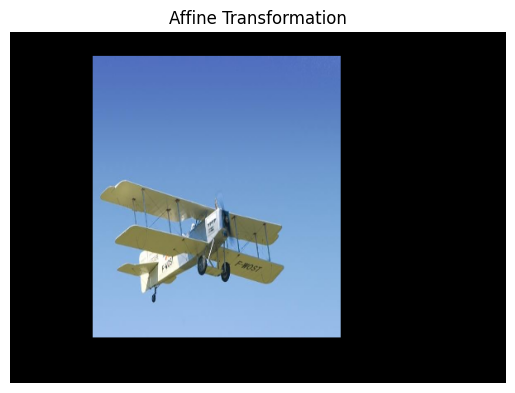

In [54]:
sx, sy = 0.5, 0.8
tx, ty = 100, 30

affine_matrix = np.float32([
    [sx, 0, tx],
    [0, sy, ty]
])

affine_img = cv2.warpAffine(img, affine_matrix, (w,h))

show_plt("Affine Transformation", affine_img)

### Rotation + Scaling

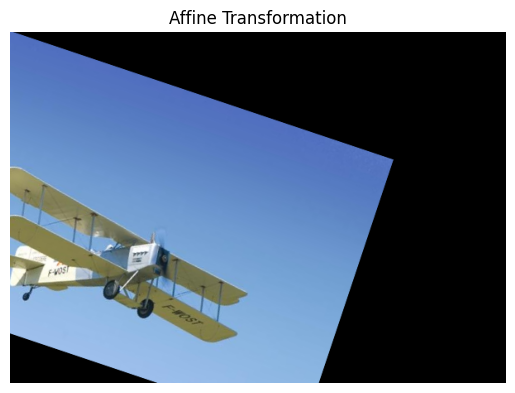

In [58]:
theta = np.deg2rad(15)
sx, sy = 0.8, 0.8

affine_matrix = np.float32([
    [sx*np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  sy*np.cos(theta), 0]
])

affine_img = cv2.warpAffine(img, affine_matrix, (w,h))

show_plt("Affine Transformation", affine_img)

### Shearing + Translation

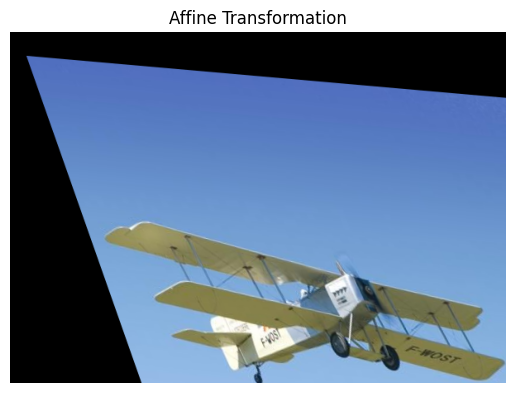

In [60]:
theta_x = np.deg2rad(70)
theta_y = np.deg2rad(85)

shx = 1/np.tan(theta_x)
shy = 1/np.tan(theta_y)
tx, ty = 20, 30

affine_matrix = np.float32([
    [1, shx, tx],
    [shy, 1 + shx*shy, ty]
])

affine_img = cv2.warpAffine(img, affine_matrix, (w,h))

show_plt("Affine Transformation", affine_img)

### Rotation + Scaling + Shearing + Translation

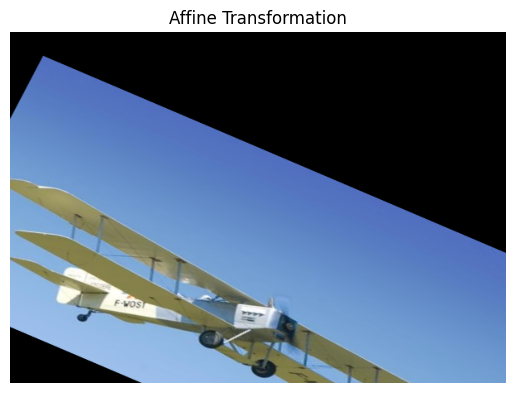

In [64]:
theta = np.deg2rad(30)
sx, sy = 1.2, 0.8

theta_x = np.deg2rad(70)
theta_y = np.deg2rad(85)

shx = 1/np.tan(theta_x)
shy = 1/np.tan(theta_y)

tx, ty = 40, 30

affine_matrix = np.float32([
    [
        sx * np.cos(theta) + shx * sy * np.sin(theta),
        -sx * np.sin(theta) + shx * sy * np.cos(theta),
        tx
    ],
    [
        shy * sx * np.cos(theta) + (1 + shx * shy) * sy * np.sin(theta),
        -shy * sx * np.sin(theta) + (1 + shx * shy) * sy * np.cos(theta),
        ty
    ],
])

affine_img = cv2.warpAffine(img, affine_matrix, (w,h))

show_plt("Affine Transformation", affine_img)

## Projective transformation

Ma trận Homography H =
 [[ 0.685389 -0.092935 80.      ]
 [-0.050584  0.597105 50.      ]
 [-0.000029 -0.000447  1.      ]]


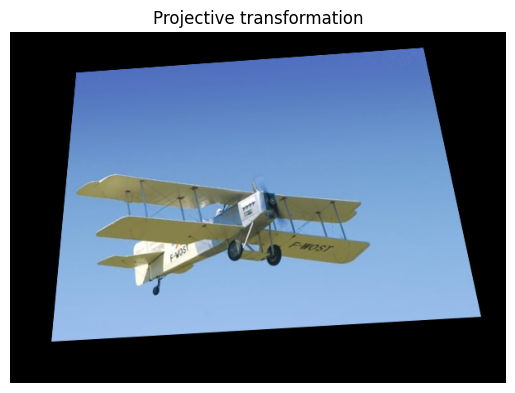

In [ ]:
src_points = np.float32([
    [0, 0],          # góc trên trái
    [w-1, 0],        # góc trên phải
    [0, h-1],        # góc dưới trái
    [w-1, h-1]       # góc dưới phải
])

dst_points = np.float32([
    [80, 50],        
    [w-100, 20],     
    [50, h-50],      
    [w-30, h-80]     
])

H = cv2.getPerspectiveTransform(src_points, dst_points)

perspective_img = cv2.warpPerspective(img, H, (w, h))

print("Ma trận Homography H =\n", H)

show_plt("Projective transformation", perspective_img)